In [6]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from torch.nn.utils.rnn import pad_sequence
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [7]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [8]:
# Load and prepare data
data = pd.read_csv("ner_dataset.csv", encoding="latin1").ffill()

# New approach: Add ENDPAD at the end of the unique words
unique_words = list(data["Word"].unique())
words = unique_words + ["ENDPAD"] # ENDPAD is now at the end

tags = list(data["Tag"].unique())

word2idx = {w: i for i, w in enumerate(words)}
tag2idx = {t: i for i, t in enumerate(tags)}
idx2tag = {i: t for t, i in tag2idx.items()}

In [ ]:
data.head(50)

,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,Sentence: 1,of,IN,O
2,Sentence: 1,demonstrators,NNS,O
3,Sentence: 1,have,VBP,O
4,Sentence: 1,marched,VBN,O
5,Sentence: 1,through,IN,O
6,Sentence: 1,London,NNP,B-geo
7,Sentence: 1,to,TO,O
8,Sentence: 1,protest,VB,O
9,Sentence: 1,the,DT,O


Essential info about tagged entities:
```
geo = Geographical Entity
org = Organization
per = Person
gpe = Geopolitical Entity
tim = Time indicator
art = Artifact
eve = Event
nat = Natural Phenomenon
```

In [9]:
print("Unique words in corpus:", data['Word'].nunique())
print("Unique tags in corpus:", data['Tag'].nunique())

Unique words in corpus: 35177
Unique tags in corpus: 17


In [10]:
print("Unique tags are:", tags)

Unique tags are: ['O', 'B-geo', 'B-gpe', 'B-per', 'I-geo', 'B-org', 'I-org', 'B-tim', 'B-art', 'I-art', 'I-per', 'I-gpe', 'I-tim', 'B-nat', 'B-eve', 'I-eve', 'I-nat']


In [11]:
# Group words by sentences
class SentenceGetter:
    def __init__(self, data):
        self.grouped = data.groupby("Sentence #", group_keys=False).apply(
            lambda s: [(w, t) for w, t in zip(s["Word"], s["Tag"])]
        )
        self.sentences = list(self.grouped)

getter = SentenceGetter(data)
sentences = getter.sentences


In [12]:
sentences[35]

[('The', 'O'),
 ('U.S.', 'B-org'),
 ('Geological', 'I-org'),
 ('Survey', 'I-org'),
 ('gave', 'O'),
 ('a', 'O'),
 ('preliminary', 'O'),
 ('estimate', 'O'),
 ('of', 'O'),
 ('the', 'O'),
 ('strength', 'O'),
 ('of', 'O'),
 ('the', 'O'),
 ('Tuesday', 'B-tim'),
 ('morning', 'I-tim'),
 ('quake', 'O'),
 ('at', 'O'),
 ('6.7', 'O'),
 ('on', 'O'),
 ('the', 'O'),
 ('Richter', 'B-geo'),
 ('scale', 'O'),
 (',', 'O'),
 ('and', 'O'),
 ('said', 'O'),
 ('the', 'O'),
 ('epicenter', 'O'),
 ('was', 'O'),
 ('close', 'O'),
 ('to', 'O'),
 ('the', 'O'),
 ('island', 'O'),
 ('of', 'O'),
 ('Nias', 'B-org'),
 ('.', 'O')]

In [13]:
# Encode sentences
X = [[word2idx[w] for w, t in s] for s in sentences]
y = [[tag2idx[t] for w, t in s] for s in sentences]

In [14]:
word2idx

{'Thousands': 0,
 'of': 1,
 'demonstrators': 2,
 'have': 3,
 'marched': 4,
 'through': 5,
 'London': 6,
 'to': 7,
 'protest': 8,
 'the': 9,
 'war': 10,
 'in': 11,
 'Iraq': 12,
 'and': 13,
 'demand': 14,
 'withdrawal': 15,
 'British': 16,
 'troops': 17,
 'from': 18,
 'that': 19,
 'country': 20,
 '.': 21,
 'Families': 22,
 'soldiers': 23,
 'killed': 24,
 'conflict': 25,
 'joined': 26,
 'protesters': 27,
 'who': 28,
 'carried': 29,
 'banners': 30,
 'with': 31,
 'such': 32,
 'slogans': 33,
 'as': 34,
 '"': 35,
 'Bush': 36,
 'Number': 37,
 'One': 38,
 'Terrorist': 39,
 'Stop': 40,
 'Bombings': 41,
 'They': 42,
 'Houses': 43,
 'Parliament': 44,
 'a': 45,
 'rally': 46,
 'Hyde': 47,
 'Park': 48,
 'Police': 49,
 'put': 50,
 'number': 51,
 'marchers': 52,
 'at': 53,
 '10,000': 54,
 'while': 55,
 'organizers': 56,
 'claimed': 57,
 'it': 58,
 'was': 59,
 '1,00,000': 60,
 'The': 61,
 'comes': 62,
 'on': 63,
 'eve': 64,
 'annual': 65,
 'conference': 66,
 'Britain': 67,
 "'s": 68,
 'ruling': 69,
 'La

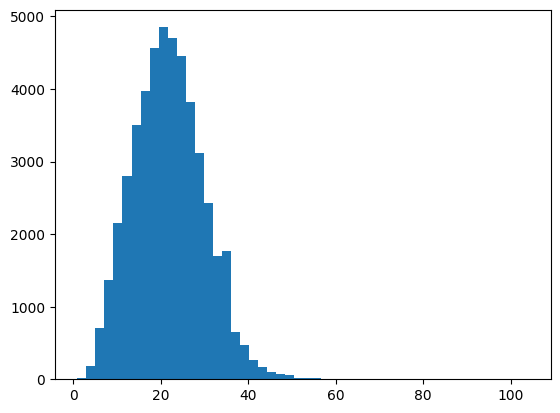

In [15]:
plt.hist([len(s) for s in sentences], bins=50)
plt.show()

In [16]:
# Pad sequences
max_len = 50
X_pad = pad_sequence([torch.tensor(seq) for seq in X], batch_first=True, padding_value=word2idx["ENDPAD"])
y_pad = pad_sequence([torch.tensor(seq) for seq in y], batch_first=True, padding_value=tag2idx["O"])
X_pad = X_pad[:, :max_len]
y_pad = y_pad[:, :max_len]

In [17]:
X_pad[0]

tensor([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
           10,    11,    12,    13,    14,     9,    15,     1,    16,    17,
           18,    19,    20,    21, 35177, 35177, 35177, 35177, 35177, 35177,
        35177, 35177, 35177, 35177, 35177, 35177, 35177, 35177, 35177, 35177,
        35177, 35177, 35177, 35177, 35177, 35177, 35177, 35177, 35177, 35177])

In [18]:
y_pad[0]

tensor([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0])

In [35]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_pad, y_pad, test_size=0.2, random_state=1)

In [36]:
# Dataset class
class NERDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "input_ids": self.X[idx],
            "labels": self.y[idx]
        }

train_loader = DataLoader(NERDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(NERDataset(X_test, y_test), batch_size=32)


In [29]:
try:
    print("X_pad is defined. Shape:", X_pad.shape)
    print("y_pad is defined. Shape:", y_pad.shape)
except NameError:
    print("X_pad or y_pad is not defined. Please ensure the cells generating these variables have been executed.")


X_pad is defined. Shape: torch.Size([47959, 50])
y_pad is defined. Shape: torch.Size([47959, 50])


In [30]:
class BiLSTMTagger(nn.Module):
    def __init__(self, vocab_size, target_size, embedding_dim=50, hidden_dim=100, pad_idx=None):
        super(BiLSTMTagger, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(0.1)
        self.lstm= nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, target_size)

    def forward(self, input_ids):
        x=self.embedding(input_ids)
        x=self.dropout(x)
        x, _ = self.lstm(x)
        return self.fc(x)

In [31]:
model = BiLSTMTagger(len(word2idx) + 1, len(tag2idx)).to(device)
loss_fn =nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [32]:
# Training and Evaluation Functions
def train_model(model, train_loader, test_loader, loss_fn, optimizer, epochs=3):
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for batch in train_loader:
          input_ids = batch["input_ids"].to(device)
          labels = batch["labels"].to(device)
          optimizer.zero_grad()
          outputs = model(input_ids)
          loss = loss_fn(outputs.view(-1,len(tag2idx)), labels.view(-1))
          loss.backward()
          optimizer.step()
          train_loss += loss.item()
        train_losses.append(train_loss)
        model.eval()
        val_loss=0
        with torch.no_grad():
          for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids)
            loss = loss_fn(outputs.view(-1,len(tag2idx)), labels.view(-1))
            val_loss += loss.item()
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")






    return train_losses, val_losses

In [33]:
def evaluate_model(model, test_loader, X_test, y_test):
    model.eval()
    true_tags, pred_tags = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=-1)
            for i in range(len(labels)):
                for j in range(len(labels[i])):
                    if labels[i][j] != tag2idx["O"]:
                        true_tags.append(idx2tag[labels[i][j].item()])
                        pred_tags.append(idx2tag[preds[i][j].item()])


In [37]:
# Run training and evaluation
train_losses, val_losses = train_model(model, train_loader, test_loader, loss_fn, optimizer, epochs=3)
evaluate_model(model, test_loader, X_test, y_test)

Epoch 1: Train Loss = 256.1227, Val Loss = 31.9065
Epoch 2: Train Loss = 108.0126, Val Loss = 22.6096
Epoch 3: Train Loss = 79.7993, Val Loss = 19.1294


Name:Prasanth T
Register Number:212224040243     


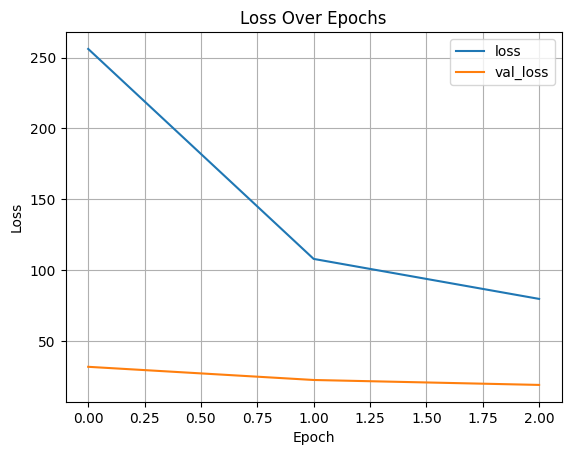

In [38]:
# Plot loss
print('Name:Prasanth T')
print('Register Number:212224040243     ')
history_df = pd.DataFrame({"loss": train_losses, "val_loss": val_losses})
history_df.plot(title="Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [39]:
# Inference and prediction
i = 125
model.eval()
sample = X_test[i].unsqueeze(0).to(device)
output = model(sample)
preds = torch.argmax(output, dim=-1).squeeze().cpu().numpy()
true = y_test[i].numpy()

print('Name: Prasanth T')
print('Register Number:212224040243')
print("{:<15} {:<10} {}\n{}".format("Word", "True", "Pred", "-" * 40))
for w_id, true_tag, pred_tag in zip(X_test[i], y_test[i], preds):
    if w_id.item() != word2idx["ENDPAD"]:
        word = words[w_id.item() - 1]
        true_label = tags[true_tag.item()]
        pred_label = tags[pred_tag]
        print(f"{word:<15} {true_label:<10} {pred_label}")

Name: Prasanth T
Register Number:212224040243
Word            True       Pred
----------------------------------------
Top             B-gpe      B-gpe
Iranian         O          O
officials       O          O
guerrillas      O          O
More            B-gpe      B-gpe
demonstrators   O          O
complain        O          O
soldiers        O          O
war             O          O
after           O          O
Revolution      O          O
Shaanxi         O          O
war             O          O
Parliament      O          O
North           B-org      B-org
miracle         I-org      I-org
Republic        O          O
March           O          O
country         O          O
